# CT Corruption & Completeness Detection — Scan‑Level Classification (LUNA16)


This notebook builds a **scan‑level** binary classifier (**label 0 = clean**, **label 1 = corrupted**) using the complete LUNA16 dataset (subsets 0–9).

### Three corruption types:
- **Shift / Jump** (scan-wide) — 20–35px shift applied to ALL slices
- **Motion blur** (scan-wide) — σ 4.0–7.0 Gaussian blur applied to ALL slices
- **Anatomical slice removal** — removes 15–35% of slices from top/bottom


1. **All 10 LUNA16 subsets** (~888 scans) — 3.3 times more data than 3 subsets (267 scans)
2. **3-way split**: 70% train / 15% validation / 15% test — proper held-out test set
3. **Scan-wide corruption** for shift and blur 
4. **2-phase training** with backbone freezing
5. **60 total epochs** (30 frozen + 30 unfrozen) — more data benefits from more training
6. **Batch size 8** — possible now with more data, gives more stable gradients
7. **Complete evaluation** on both validation AND held-out test set
8. **Per-corruption-type analysis** on test set for final reporting

In [ ]:
import time
NOTEBOOK_START = time.time()

In [ ]:
!pip -q install torch torchvision torchaudio

In [ ]:
# 1) Imports
import os, glob, math, random, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Medical image IO
import SimpleITK as sitk

# Resize + blur helpers
from scipy.ndimage import zoom, gaussian_filter

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, roc_auc_score,
    ConfusionMatrixDisplay
)

print("All imports done.")

## 2) Discover all LUNA16 subsets

We auto-discover all subset folders (subset0 through subset9) and collect every `.mhd` file.
This gives us ~888 CT scans — 3.3× more training data than v3.

In [ ]:

# subsets (subset0-9)


BASE_DIR = "/kaggle/input/datasets/fardinabdullaacanto"
MEDICALNET_CKPT = os.path.join(BASE_DIR, "medicalnet-weights/resnet_18_23dataset.pth")

# Auto-discover subsets
all_mhd_paths = []
subset_counts = {}

for i in range(10):
    # Try common path patterns for each subset
    candidates = [
        os.path.join(BASE_DIR, f"subset{i}", f"subset{i}"),
        os.path.join(BASE_DIR, f"subset{i}", f"subset{i}", f"subset{i}"),
        os.path.join(BASE_DIR, f"subset{i}"),
    ]
    
    found = False
    for path in candidates:
        mhds = sorted(glob.glob(os.path.join(path, "*.mhd")))
        if len(mhds) > 0:
            all_mhd_paths.extend(mhds)
            subset_counts[f"subset{i}"] = len(mhds)
            print(f"  subset{i}: {len(mhds):3d} scans  ({path})")
            found = True
            break
    
    if not found:
        # Try recursive search
        mhds = sorted(glob.glob(os.path.join(BASE_DIR, f"subset{i}", "**", "*.mhd"), recursive=True))
        if len(mhds) > 0:
            all_mhd_paths.extend(mhds)
            subset_counts[f"subset{i}"] = len(mhds)
            print(f"  subset{i}: {len(mhds):3d} scans  (recursive)")
        else:
            print(f"  subset{i}:   0 scans  (NOT FOUND)")

print(f"\nTOTAL: {len(all_mhd_paths)} scans across {len(subset_counts)} subsets")

In [ ]:

#all hyperparameters in one place


OUT_DIR = Path("./dataset_npz_v4")

# Preprocessing
TARGET_SHAPE = (64, 128, 128)   # (D, H, W) after resize
HU_MIN, HU_MAX = -1000, 400     # lung window

# Corruption parameters — SCAN-WIDE 
SHIFT_RANGE = (20, 35)           # pixel shift applied to ALL slices
BLUR_SIGMA_RANGE = (4.0, 7.0)   # gaussian sigma applied to ALL slices
SLICE_REMOVAL_FRAC = (0.15, 0.35)  # fraction of slices to remove

# Data splits — NEW: proper 3-way split
TRAIN_FRAC = 0.70    # ~622 scans for training
VAL_FRAC   = 0.15    # ~133 scans for validation (during training)
TEST_FRAC  = 0.15    # ~133 scans for final evaluation (never seen during training)

# Training — 2-phase 
BATCH_SIZE = 8         # larger batch now that we have more data
PHASE1_EPOCHS = 30     # frozen backbone
PHASE2_EPOCHS = 30     # unfrozen fine-tuning
PHASE1_LR = 3e-4
PHASE2_LR = 1e-5

print(f"Dataset: {len(all_mhd_paths)} scans")
print(f"Split: {TRAIN_FRAC:.0%} train / {VAL_FRAC:.0%} val / {TEST_FRAC:.0%} test")
print(f"Training: {PHASE1_EPOCHS}+{PHASE2_EPOCHS} = {PHASE1_EPOCHS+PHASE2_EPOCHS} epochs, batch={BATCH_SIZE}")
print(f"Corruption: shift {SHIFT_RANGE}px, blur σ {BLUR_SIGMA_RANGE}, removal {SLICE_REMOVAL_FRAC}")
print("\nConfiguration set (v4).")

## 3) Load a CT volume (LUNA16 .mhd/.raw)
Returns a NumPy array in **(D, H, W)** order. D varies per scan, H×W is always 512×512.

In [ ]:
def load_mhd(path: str) -> np.ndarray:
    """Load .mhd/.raw CT volume. Returns (D, H, W) float32 in HU."""
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    return arr.astype(np.float32)

# Test load
vol0 = load_mhd(all_mhd_paths[0])
print("Volume 0 shape:", vol0.shape, "HU range:", f"{vol0.min():.0f} to {vol0.max():.0f}")

vol1 = load_mhd(all_mhd_paths[len(all_mhd_paths)//2])
print("Volume mid shape:", vol1.shape, "HU range:", f"{vol1.min():.0f} to {vol1.max():.0f}")

## 4) Visualize slices
CT values are in Hounsfield Units (HU). For lung imaging, we use a window of [-1000, 400].

In [ ]:
def show_slice(vol, idx, vmin=-1000, vmax=400, title=None):
    """Display a single slice."""
    plt.figure(figsize=(4, 4))
    plt.imshow(vol[idx], cmap="gray", vmin=vmin, vmax=vmax)
    plt.axis("off")
    plt.title(title or f"slice {idx}")
    plt.show()

def show_comparison(vol_a, vol_b, idx, title_a="A", title_b="B"):
    """Side-by-side comparison with absolute difference."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(vol_a[idx], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(title_a); axes[0].axis("off")
    axes[1].imshow(vol_b[idx], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(title_b); axes[1].axis("off")
    axes[2].imshow(np.abs(vol_a[idx] - vol_b[idx]), cmap="hot")
    axes[2].set_title("Absolute Difference"); axes[2].axis("off")
    plt.tight_layout()
    plt.show()

mid = vol0.shape[0] // 2
show_slice(vol0, mid, title="Original CT (lung window)")

## 5) Preprocessing
Three steps applied to every scan:
1. **Clip** HU to lung window [-1000, 400]
2. **Normalize** to [0, 1]
3. **Resize** to fixed shape (64, 128, 128) so all scans have the same dimensions

In [ ]:
def clip_hu(vol, lo=-1000, hi=400):
    return np.clip(vol, lo, hi)

def normalize_01(vol, lo=-1000, hi=400):
    return ((vol - lo) / (hi - lo)).astype(np.float32)

def resize_dhw(vol, out_shape=(64, 128, 128)):
    D, H, W = vol.shape
    d2, h2, w2 = out_shape
    return zoom(vol, (d2/D, h2/H, w2/W), order=1).astype(np.float32)

def preprocess(vol_hu, out_shape=TARGET_SHAPE):
    """Full pipeline: clip -> normalize -> resize."""
    vol = clip_hu(vol_hu, HU_MIN, HU_MAX)
    vol = normalize_01(vol, HU_MIN, HU_MAX)
    vol = resize_dhw(vol, out_shape)
    return vol

vol_p = preprocess(vol0)
print("Preprocessed:", vol_p.shape, f"range [{vol_p.min():.2f}, {vol_p.max():.2f}]")
show_slice(vol_p, vol_p.shape[0]//2, vmin=0, vmax=1, title="Preprocessed (0-1)")

## 6) Corruption functions — SCAN-WIDE at full resolution


### Three corruption types:
1. **Shift** — shift ALL slices by 20–35px (simulates patient movement)
2. **Blur** — Gaussian blur ALL slices with σ 4.0–7.0 (simulates breathing/motion)
3. **Slice removal** — remove 15–35% of slices (simulates incomplete scan)

In [ ]:
def apply_shift_scanwide(vol_hu, dx, dy):
    """Shift ALL slices by (dx, dy) at full resolution."""
    out = vol_hu.copy()
    for z in range(out.shape[0]):
        out[z] = np.roll(out[z], shift=(dy, dx), axis=(0, 1))
    return out

def apply_blur_scanwide(vol_hu, sigma):
    """Gaussian blur ALL slices at full resolution."""
    out = vol_hu.copy()
    for z in range(out.shape[0]):
        out[z] = gaussian_filter(out[z], sigma=sigma)
    return out

def apply_slice_removal(vol_hu, removal_frac, side="random"):
    """Remove slices from top/bottom to simulate incomplete scans."""
    D = vol_hu.shape[0]
    n_remove = max(1, int(D * removal_frac))

    if side == "random":
        side = np.random.choice(["top", "bottom", "both"])

    if side == "top":
        out = vol_hu[n_remove:]
        info = {"removal_side": "top", "slices_removed": n_remove, "original_D": D}
    elif side == "bottom":
        out = vol_hu[:D - n_remove]
        info = {"removal_side": "bottom", "slices_removed": n_remove, "original_D": D}
    else:
        n_top = n_remove // 2
        n_bot = n_remove - n_top
        out = vol_hu[n_top:D - n_bot]
        info = {"removal_side": "both", "slices_removed": n_remove, "original_D": D}

    return out, info

print("Corruption functions defined (scan-wide shift & blur).")

In [ ]:
# Demo all 3 corruption types
vol_full = load_mhd(all_mhd_paths[0])
vol_full_norm = normalize_01(clip_hu(vol_full))
mid = vol_full.shape[0] // 2

# Shift
vol_shifted = apply_shift_scanwide(vol_full, dx=25, dy=-20)
vol_shifted_norm = normalize_01(clip_hu(vol_shifted))
print("=== SCAN-WIDE SHIFT (dx=25, dy=-20) ===")
show_comparison(vol_full_norm, vol_shifted_norm, mid, "Clean", "Shifted")

# Blur
vol_blurred = apply_blur_scanwide(vol_full, sigma=5.0)
vol_blurred_norm = normalize_01(clip_hu(vol_blurred))
print("=== SCAN-WIDE BLUR (sigma=5.0) ===")
show_comparison(vol_full_norm, vol_blurred_norm, mid, "Clean", "Blurred")

# Slice removal
vol_trunc, info = apply_slice_removal(vol_full, 0.25, "top")
vol_trunc_pp = preprocess(vol_trunc)
vol_clean_pp = preprocess(vol_full)
print(f"=== SLICE REMOVAL: removed {info['slices_removed']} slices from {info['removal_side']} ===")
show_comparison(vol_clean_pp, vol_trunc_pp, TARGET_SHAPE[0]//2, "Clean", "25% removed")

## 7) Scan-level labeling policy
- **label 0** = clean scan
- **label 1** = corrupted (shift OR blur OR slice removal)

Each corrupted scan gets exactly one corruption type, chosen randomly with equal probability.

In [ ]:
def pick_scan_label(D_original, mode="random", p_corrupt=0.5,
                    corrupt_types=("shift", "blur", "slice_removal"), rng=None):
    """Assign clean/corrupt label and corruption parameters."""
    rng = rng or np.random.default_rng()

    if mode == "clean":
        return 0, {"type": "clean"}
    if mode == "corrupt":
        label = 1
    elif mode == "random":
        label = int(rng.random() < p_corrupt)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if label == 0:
        return 0, {"type": "clean"}

    ctype = str(rng.choice(corrupt_types))
    meta = {"type": ctype}

    if ctype == "shift":
        dx = int(rng.integers(SHIFT_RANGE[0], SHIFT_RANGE[1] + 1))
        dy = int(rng.integers(SHIFT_RANGE[0], SHIFT_RANGE[1] + 1))
        dx = dx if rng.random() > 0.5 else -dx
        dy = dy if rng.random() > 0.5 else -dy
        meta.update({"dx": dx, "dy": dy})

    elif ctype == "blur":
        sigma = float(rng.uniform(BLUR_SIGMA_RANGE[0], BLUR_SIGMA_RANGE[1]))
        meta["sigma"] = sigma

    elif ctype == "slice_removal":
        frac = float(rng.uniform(SLICE_REMOVAL_FRAC[0], SLICE_REMOVAL_FRAC[1]))
        side = str(rng.choice(["top", "bottom", "both"]))
        meta.update({"removal_frac": frac, "side": side})

    return label, meta

# Test
rng = np.random.default_rng(42)
for _ in range(6):
    y, m = pick_scan_label(200, mode="random", rng=rng)
    print(f"  label={y}  {m}")

## 8) Build dataset — 3-way split (train / val / test)

3-way split.
- **Train (70%)**: model learns from these
- **Validation (15%)**: used during training to pick the best model
- **Test (15%)**: NEVER seen during training — final evaluation only

Each split has balanced 50/50 clean/corrupt ratio.

In [ ]:
def corrupt_and_preprocess(vol_hu, meta, rng=None):
    """Apply corruption at full resolution, then preprocess."""
    ctype = meta["type"]

    if ctype == "clean":
        return preprocess(vol_hu)
    elif ctype == "shift":
        return preprocess(apply_shift_scanwide(vol_hu, meta["dx"], meta["dy"]))
    elif ctype == "blur":
        return preprocess(apply_blur_scanwide(vol_hu, meta["sigma"]))
    elif ctype == "slice_removal":
        vol_trunc, info = apply_slice_removal(vol_hu, meta["removal_frac"], meta["side"])
        meta.update(info)
        return preprocess(vol_trunc)
    else:
        raise ValueError(f"Unknown type: {ctype}")


def make_dataset(mhd_list, split="train", seed=0):
    """Build dataset with balanced clean/corrupt labels."""
    rng = np.random.default_rng(seed)
    chosen = list(mhd_list)
    rng.shuffle(chosen)

    half = len(chosen) // 2
    stats = {"clean": 0, "shift": 0, "blur": 0, "slice_removal": 0}

    for i, p in enumerate(chosen):
        mode = "corrupt" if i < half else "clean"
        vol_hu = load_mhd(p)
        label, meta = pick_scan_label(vol_hu.shape[0], mode=mode, rng=rng)
        vol_out = corrupt_and_preprocess(vol_hu, meta, rng)

        save_path = OUT_DIR / split / f"scan_{i:04d}_{meta['type']}.npz"
        np.savez_compressed(save_path,
            vol=vol_out.astype(np.float32),
            label=np.int64(label),
            ctype=str(meta["type"]),
            meta_str=str(meta))

        stats[meta["type"]] += 1
        if (i + 1) % 50 == 0:
            print(f"  [{split}] {i+1}/{len(chosen)}")

    print(f"  {split}: {len(chosen)} scans — {stats}")
    return stats



# creatiing 3-way split and build datasets


if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
for split in ["train", "val", "test"]:
    (OUT_DIR / split).mkdir(parents=True, exist_ok=True)

random.seed(42)
paths = all_mhd_paths.copy()
random.shuffle(paths)

n_total = len(paths)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)
n_test = n_total - n_train - n_val

train_paths = paths[:n_train]
val_paths = paths[n_train:n_train + n_val]
test_paths = paths[n_train + n_val:]

print(f"Total: {n_total} scans")
print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")
print()

print("Building training set...")
train_stats = make_dataset(train_paths, "train", seed=1)
print("\nBuilding validation set...")
val_stats = make_dataset(val_paths, "val", seed=2)
print("\nBuilding test set...")
test_stats = make_dataset(test_paths, "test", seed=3)

In [ ]:
def label_stats(folder):
    labels, ctypes = [], []
    for p in Path(folder).glob("*.npz"):
        d = np.load(p, allow_pickle=True)
        labels.append(int(d["label"]))
        ctypes.append(str(d["ctype"]))
    labels = np.array(labels)
    counts = {}
    for ct in ctypes:
        counts[ct] = counts.get(ct, 0) + 1
    return {"N": len(labels), "clean": int((labels==0).sum()),
            "corrupt": int((labels==1).sum()), "types": counts}

for split in ["train", "val", "test"]:
    s = label_stats(OUT_DIR / split)
    print(f"{split:5s}: {s}")

## 9) Visualize saved samples

In [ ]:
sample_paths = sorted((OUT_DIR/"train").glob("*.npz"))[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, p in enumerate(sample_paths):
    if i >= len(axes): break
    d = np.load(p, allow_pickle=True)
    vol, label, ctype = d["vol"], int(d["label"]), str(d["ctype"])
    axes[i].imshow(vol[vol.shape[0]//2], cmap="gray", vmin=0, vmax=1)
    color = "green" if label == 0 else "red"
    axes[i].set_title(f"label={label} ({ctype})", fontsize=10, color=color)
    axes[i].axis("off")

plt.suptitle("Training samples (green=clean, red=corrupted)", fontsize=14)
plt.tight_layout()
plt.show()

## 10) PyTorch Dataset + DataLoaders
Input shape: `(1, 64, 128, 128)` — 1 channel (grayscale), 64 depth, 128×128 per slice.

In [ ]:
class NPZScanDataset(Dataset):
    def __init__(self, folder):
        self.paths = sorted(Path(folder).glob("*.npz"))
        if len(self.paths) == 0:
            raise FileNotFoundError(f"No .npz in {folder}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        d = np.load(self.paths[idx], allow_pickle=True)
        vol = d["vol"].astype(np.float32)
        label = int(d["label"])
        vol = np.expand_dims(vol, axis=0)  # (1, D, H, W)
        return torch.from_numpy(vol), torch.tensor(label, dtype=torch.float32)

train_ds = NPZScanDataset(OUT_DIR / "train")
val_ds   = NPZScanDataset(OUT_DIR / "val")
test_ds  = NPZScanDataset(OUT_DIR / "test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
x, y = next(iter(train_loader))
print(f"Batch shape: {tuple(x.shape)} (B, C, D, H, W)")

## 11) Model — MedicalNet ResNet-18 with backbone freezing

**Architecture:** MedicalNet pretrained 3D ResNet-18 (33M params, pretrained on 23 medical datasets)

**Classification head:** `AdaptiveAvgPool3d(1) → Dropout(0.5) → Linear(512, 1)`

**Backbone freezing:** conv1, bn1, layer1, layer2 frozen initially.
Only layer3, layer4, and classification head train in Phase 1.
This prevents overwriting useful pretrained features.

In [ ]:
!git clone https://github.com/Tencent/MedicalNet.git

In [ ]:
import sys
sys.path.append("/kaggle/working/MedicalNet")

import torch
import torch.nn as nn
from models import resnet

class MedicalNetResNet18Binary(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet.resnet18(
            sample_input_D=TARGET_SHAPE[0],
            sample_input_H=TARGET_SHAPE[1],
            sample_input_W=TARGET_SHAPE[2],
            num_seg_classes=2,
            shortcut_type='A',
            no_cuda=False
        )
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MedicalNetResNet18Binary().to(device)
print(f"Device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
def load_medicalnet_weights(model, ckpt_path):
    if not os.path.isfile(ckpt_path):
        print(f"WARNING: {ckpt_path} not found. Training from scratch.")
        return
    ckpt = torch.load(ckpt_path, map_location="cpu")
    sd = ckpt.get("state_dict", ckpt)
    model_sd = model.state_dict()
    new_sd = {}
    for k, v in sd.items():
        k = k.replace("module.", "")
        if not k.startswith("backbone."):
            k = "backbone." + k
        if k in model_sd and v.shape == model_sd[k].shape:
            new_sd[k] = v
    missing, _ = model.load_state_dict(new_sd, strict=False)
    print(f"Loaded {len(new_sd)}/{len(model_sd)} tensors from MedicalNet checkpoint.")
    print(f"Missing (seg head + fc): {len(missing)} keys")

load_medicalnet_weights(model, MEDICALNET_CKPT)

# Freeze early layers
def freeze_early_layers(model):
    frozen = 0
    for name, param in model.named_parameters():
        if any(name.startswith(f"backbone.{l}") for l in ["conv1", "bn1", "layer1", "layer2"]):
            param.requires_grad = False
            frozen += 1
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Frozen {frozen} tensors. Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True
    print(f"All {sum(p.numel() for p in model.parameters()):,} parameters now trainable")

freeze_early_layers(model)

## 12) Training — 2-Phase Strategy

**Phase 1 (30 epochs):** Early backbone frozen. Only layer3 + layer4 + head train.
Higher LR (3e-4) since fewer parameters update. Head learns to use pretrained features.

**Phase 2 (30 epochs):** All layers unfrozen. Lower LR (1e-5) for gentle fine-tuning.
Now the entire network adapts to our specific task.



In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x).view(-1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y).sum().item()
        n += x.size(0)
    return total_loss / max(1, n), correct / max(1, n)

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_probs, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x).view(-1)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        total_loss += loss.item() * x.size(0)
        correct += (preds == y).sum().item()
        n += x.size(0)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_labels.extend(y.cpu().numpy().tolist())
    return total_loss / max(1,n), correct / max(1,n), np.array(all_probs), np.array(all_labels)


criterion = nn.BCEWithLogitsLoss()
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[], "lr":[], "phase":[]}
best_val_acc = 0.0
best_epoch = 0
global_epoch = 0

# ── PHASE 1: Frozen backbone ──
print("=" * 75)
print(f"PHASE 1: Frozen backbone | {PHASE1_EPOCHS} epochs | LR={PHASE1_LR}")
print("=" * 75)

opt1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR)
sched1 = CosineAnnealingLR(opt1, T_max=PHASE1_EPOCHS, eta_min=1e-6)

for ep in range(1, PHASE1_EPOCHS + 1):
    global_epoch += 1
    tr_l, tr_a = train_one_epoch(model, train_loader, opt1, criterion)
    va_l, va_a, _, _ = eval_one_epoch(model, val_loader, criterion)
    sched1.step()
    lr = opt1.param_groups[0]["lr"]
    history["train_loss"].append(tr_l); history["train_acc"].append(tr_a)
    history["val_loss"].append(va_l); history["val_acc"].append(va_a)
    history["lr"].append(lr); history["phase"].append(1)
    if va_a > best_val_acc:
        best_val_acc = va_a; best_epoch = global_epoch
        torch.save(model.state_dict(), "best_model.pth")
    if ep % 5 == 0 or ep == 1:
        print(f"  P1 {ep:02d}/{PHASE1_EPOCHS} | loss {tr_l:.4f} acc {tr_a:.3f} | val {va_l:.4f} acc {va_a:.3f} | lr {lr:.2e}")

print(f"Phase 1 best: {best_val_acc:.3f}")

# ── PHASE 2: Full fine-tuning ──
print()
print("=" * 75)
print(f"PHASE 2: Full fine-tuning | {PHASE2_EPOCHS} epochs | LR={PHASE2_LR}")
print("=" * 75)

unfreeze_all(model)
opt2 = torch.optim.Adam(model.parameters(), lr=PHASE2_LR)
sched2 = CosineAnnealingLR(opt2, T_max=PHASE2_EPOCHS, eta_min=1e-7)

for ep in range(1, PHASE2_EPOCHS + 1):
    global_epoch += 1
    tr_l, tr_a = train_one_epoch(model, train_loader, opt2, criterion)
    va_l, va_a, _, _ = eval_one_epoch(model, val_loader, criterion)
    sched2.step()
    lr = opt2.param_groups[0]["lr"]
    history["train_loss"].append(tr_l); history["train_acc"].append(tr_a)
    history["val_loss"].append(va_l); history["val_acc"].append(va_a)
    history["lr"].append(lr); history["phase"].append(2)
    if va_a > best_val_acc:
        best_val_acc = va_a; best_epoch = global_epoch
        torch.save(model.state_dict(), "best_model.pth")
    if ep % 5 == 0 or ep == 1:
        print(f"  P2 {ep:02d}/{PHASE2_EPOCHS} | loss {tr_l:.4f} acc {tr_a:.3f} | val {va_l:.4f} acc {va_a:.3f} | lr {lr:.2e}")

TOTAL_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS
print()
print("=" * 75)
print(f"Done. {TOTAL_EPOCHS} epochs. Best val accuracy: {best_val_acc:.3f} (epoch {best_epoch})")
print("=" * 75)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pb = PHASE1_EPOCHS

axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
axes[0].axvline(x=pb, color="red", ls="--", alpha=0.7, label="Phase 1→2")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train"); axes[1].plot(history["val_acc"], label="Val")
axes[1].axhline(y=0.5, color="gray", ls="--", alpha=0.5, label="Random")
axes[1].axvline(x=pb, color="red", ls="--", alpha=0.7, label="Phase 1→2")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history["lr"], color="green")
axes[2].axvline(x=pb, color="red", ls="--", alpha=0.7, label="Phase 1→2")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR"); axes[2].set_title("Learning Rate"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 13) Evaluation on Validation Set
Loading the best model and computing all metrics.

In [ ]:
# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=device))
print(f"Loaded best model (epoch {best_epoch})")

val_loss, val_acc, val_probs, val_labels = eval_one_epoch(model, val_loader, criterion)
val_preds = (val_probs >= 0.5).astype(int)

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Validation Loss:    {val_loss:.4f}")

In [ ]:
# Confusion Matrix — Validation
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Clean", "Corrupted"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — Validation Set")
plt.tight_layout(); plt.show()

In [ ]:
# Classification Report — Validation
precision, recall, f1, _ = precision_recall_fscore_support(val_labels, val_preds, average="binary", zero_division=0)
try:
    auc = roc_auc_score(val_labels, val_probs)
except ValueError:
    auc = float("nan")

print("=" * 55)
print("  VALIDATION SET — Classification Report")
print("=" * 55)
print(classification_report(val_labels, val_preds, target_names=["Clean", "Corrupted"], zero_division=0))
print(f"ROC-AUC: {auc:.4f}")
print("=" * 55)

In [ ]:
# Per-corruption-type — Validation
print("--- Per-Corruption-Type (Validation) ---\n")
val_ctypes = np.array([str(np.load(p, allow_pickle=True)["ctype"]) for p in sorted((OUT_DIR/"val").glob("*.npz"))])

print(f"{'Type':<18} {'N':>5} {'Correct':>8} {'Accuracy':>10}")
print("-" * 46)
for ct in ["clean", "shift", "blur", "slice_removal"]:
    mask = val_ctypes == ct
    if mask.sum() == 0: continue
    n = mask.sum()
    correct = (val_labels[mask] == val_preds[mask]).sum()
    print(f"  {ct:<16} {n:>5} {correct:>8} {correct/n:>10.3f}")

## 14) Final Evaluation on HELD-OUT TEST SET

This is the most important evaluation. The test set was **never seen during training**
— not even for model selection. This gives the truest measure of how well the model generalizes.

In [ ]:
# Evaluate on test set
test_loss, test_acc, test_probs, test_labels = eval_one_epoch(model, test_loader, criterion)
test_preds = (test_probs >= 0.5).astype(int)

print(f"TEST Accuracy: {test_acc:.4f}")
print(f"TEST Loss:     {test_loss:.4f}")

In [ ]:
# Confusion Matrix — Test
cm_test = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_test, display_labels=["Clean", "Corrupted"]).plot(ax=ax, cmap="Greens", values_format="d")
ax.set_title("Confusion Matrix — TEST SET (held-out)")
plt.tight_layout(); plt.show()

In [ ]:
# Full metrics — Test
t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="binary", zero_division=0)
try:
    t_auc = roc_auc_score(test_labels, test_probs)
except ValueError:
    t_auc = float("nan")

print("=" * 55)
print("  TEST SET — Classification Report (FINAL)")
print("=" * 55)
print(classification_report(test_labels, test_preds, target_names=["Clean", "Corrupted"], zero_division=0))
print(f"ROC-AUC: {t_auc:.4f}")
print("=" * 55)

print("\n" + "=" * 55)
print("  FINAL BENCHMARKING — MedicalNet ResNet-18 (Binary)")
print("=" * 55)
print(f"{'Metric':<20} {'Validation':>12} {'Test':>12}")
print("-" * 48)
print(f"{'Accuracy':<20} {val_acc:>12.4f} {test_acc:>12.4f}")
print(f"{'Precision':<20} {precision:>12.4f} {t_prec:>12.4f}")
print(f"{'Recall':<20} {recall:>12.4f} {t_rec:>12.4f}")
print(f"{'F1-Score':<20} {f1:>12.4f} {t_f1:>12.4f}")
print(f"{'ROC-AUC':<20} {auc:>12.4f} {t_auc:>12.4f}")
print("-" * 48)

In [ ]:
# Per-corruption-type — TEST SET
print("--- Per-Corruption-Type (TEST SET — FINAL) ---\n")
test_ctypes = np.array([str(np.load(p, allow_pickle=True)["ctype"]) for p in sorted((OUT_DIR/"test").glob("*.npz"))])

print(f"{'Type':<18} {'N':>5} {'Correct':>8} {'Accuracy':>10}")
print("-" * 46)
for ct in ["clean", "shift", "blur", "slice_removal"]:
    mask = test_ctypes == ct
    if mask.sum() == 0: continue
    n = mask.sum()
    correct = (test_labels[mask] == test_preds[mask]).sum()
    print(f"  {ct:<16} {n:>5} {correct:>8} {correct/n:>10.3f}")

## 15) Single-scan inference demo
Testing the model on individual scans with known ground truth.

In [ ]:
@torch.no_grad()
def predict_scan(model, vol01):
    model.eval()
    x = torch.from_numpy(vol01[None, None, ...]).float().to(device)
    logit = model(x).item()
    prob = float(torch.sigmoid(torch.tensor(logit)))
    return prob, int(prob >= 0.5)

# Use a scan from the TEST set paths (never used in training)
test_scan_path = test_paths[0]
vol_raw = load_mhd(test_scan_path)

# Test 1: Clean
vol_clean = preprocess(vol_raw)
p1, pred1 = predict_scan(model, vol_clean)
print(f"Test 1 — Clean scan:")
print(f"  P(corrupted) = {p1:.4f} → {'CORRUPTED' if pred1 else 'CLEAN'}")

# Test 2: 30% slices removed
vol_trunc, _ = apply_slice_removal(vol_raw, 0.30, "top")
vol_trunc_pp = preprocess(vol_trunc)
p2, pred2 = predict_scan(model, vol_trunc_pp)
print(f"\nTest 2 — 30% slices removed:")
print(f"  P(corrupted) = {p2:.4f} → {'CORRUPTED' if pred2 else 'CLEAN'}")

# Test 3: Scan-wide shift
vol_shift = apply_shift_scanwide(vol_raw, dx=28, dy=-22)
vol_shift_pp = preprocess(vol_shift)
p3, pred3 = predict_scan(model, vol_shift_pp)
print(f"\nTest 3 — Scan-wide shift (dx=28, dy=-22):")
print(f"  P(corrupted) = {p3:.4f} → {'CORRUPTED' if pred3 else 'CLEAN'}")

# Test 4: Scan-wide blur
vol_blur = apply_blur_scanwide(vol_raw, sigma=5.5)
vol_blur_pp = preprocess(vol_blur)
p4, pred4 = predict_scan(model, vol_blur_pp)
print(f"\nTest 4 — Scan-wide blur (sigma=5.5):")
print(f"  P(corrupted) = {p4:.4f} → {'CORRUPTED' if pred4 else 'CLEAN'}")

# Visuals
print("\n--- Visual comparisons ---")
show_comparison(vol_clean, vol_trunc_pp, TARGET_SHAPE[0]//2, "Clean", "30% removed")
show_comparison(vol_clean, vol_shift_pp, TARGET_SHAPE[0]//2, "Clean", "Shifted")
show_comparison(vol_clean, vol_blur_pp, TARGET_SHAPE[0]//2, "Clean", "Blurred")

## 16) Resource & Efficiency Summary

In [ ]:
NOTEBOOK_END = time.time()
total_seconds = NOTEBOOK_END - NOTEBOOK_START

if torch.cuda.is_available():
    gpu_mem = torch.cuda.max_memory_allocated() / (1024 ** 3)
    gpu_name = torch.cuda.get_device_name(0)
else:
    gpu_mem, gpu_name = 0.0, "CPU"

TOTAL_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS

print("=" * 55)
print("  RESOURCE SUMMARY")
print("=" * 55)
print(f"  Device:             {gpu_name}")
print(f"  Peak GPU memory:    {gpu_mem:.2f} GB")
print(f"  Total runtime:      {total_seconds:.0f}s ({total_seconds/60:.1f} min)")
print(f"  Phase 1:            {PHASE1_EPOCHS} epochs (frozen, LR={PHASE1_LR})")
print(f"  Phase 2:            {PHASE2_EPOCHS} epochs (unfrozen, LR={PHASE2_LR})")
print(f"  Total epochs:       {TOTAL_EPOCHS}")
print(f"  Dataset:            {len(all_mhd_paths)} scans (10 subsets)")
print(f"  Train / Val / Test: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")
print(f"  Batch size:         {BATCH_SIZE}")
print(f"  Best val accuracy:  {best_val_acc:.3f} (epoch {best_epoch})")
print(f"  Test accuracy:      {test_acc:.3f}")
print("=" * 55)

## 17) Save & Download Model

In [ ]:
import os
print("Model:", os.path.abspath("best_model.pth"))
print("Size:", round(os.path.getsize("best_model.pth") / 1e6, 1), "MB")

from IPython.display import FileLink
FileLink("best_model.pth")

# notes on previous versions

# Experimental Results – Scan-Level Corruption Detection

---

# small 3D CNN — Subset0 Only (89 Scans)

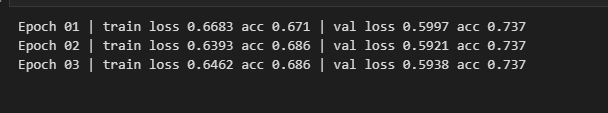

### Summary

In this experiment, the Small 3D CNN was trained using only **subset0 (89 scans)**.

**Observed Performance:**

* Training accuracy ≈ 0.67
* Validation accuracy ≈ 0.73
* Validation loss ≈ 0.59

### Interpretation

With limited data (89 scans), the model was able to learn basic corruption patterns (shift and blur), achieving moderate validation accuracy. However, the model showed signs of limited generalization due to restricted dataset size.

This serves as a baseline performance for the task.

---

# small 3D CNN — Subset0 + Subset1 (178 Scans)

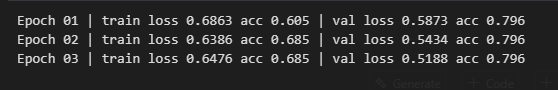

### Summary

The dataset size was doubled by combining subset0 and subset1 (178 scans total).

**Observed Performance:**

* Training accuracy ≈ 0.64–0.68
* Validation accuracy ≈ 0.79
* Validation loss decreased compared to subset0-only

### Interpretation

Although training accuracy slightly decreased, validation accuracy improved significantly (≈ 0.73 → ≈ 0.79).

This indicates:

* Reduced overfitting
* Improved generalization
* More robust feature learning

Increasing dataset size improved model performance more than increasing model complexity at this stage.

---

# 3D ResNet — Subset0 + Subset1 (Few Epochs)

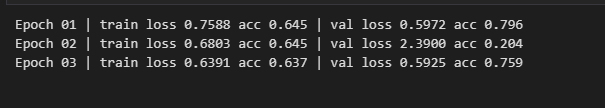

### Summary

The Small 3D CNN was replaced with a deeper **3D ResNet** architecture while using the same combined dataset (178 scans).

Initial training with only a few epochs showed instability:

* Validation accuracy fluctuated heavily
* Occasional validation collapse (e.g., large loss spikes)

### Interpretation

The deeper model introduced:

* Higher model capacity
* Increased training sensitivity
* Greater variance with small datasets

This instability was expected due to:

* Limited dataset size
* Few training epochs
* Larger parameter count

At this stage, deeper architecture alone did not guarantee better performance.

---

#  3D ResNet — Subset0 + Subset1 (LR = 1e-4, 20 Epochs)

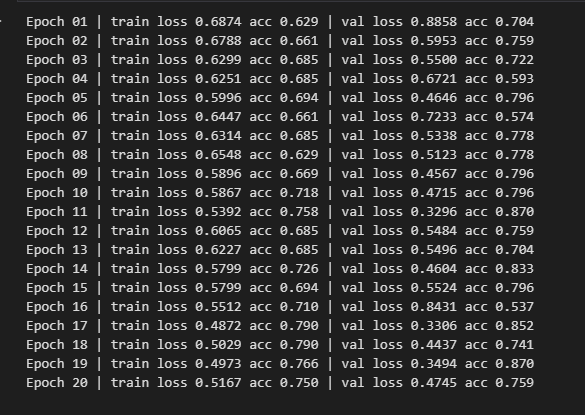

### Summary

After tuning:

* Learning rate reduced to 1e-4
* Training extended to 20 epochs

**Observed Performance:**

* Training accuracy increased steadily (~0.63 → ~0.75–0.79)
* Validation accuracy peaked at **~0.87**
* Validation performance stabilized
* Loss decreased overall

### Interpretation

With proper tuning, 3D ResNet outperformed the Small CNN.

Key observations:

* Deeper model benefits from longer training
* Lower learning rate improves stability
* Larger dataset enables deeper architectures to generalize better
* Validation accuracy improved from ~0.79 (Small CNN) to ~0.87 (ResNet)

This suggests that:

* Model capacity must be matched with sufficient data
* Hyperparameter tuning is critical for deep 3D models

---

#  Overall Comparison



| Experiment | Model                                     | Dataset   | Corruption                               | Best Val Acc | ROC-AUC     | Stability     |
| ---------- | ----------------------------------------- | --------- | ---------------------------------------- | ------------ | ----------- | ------------- |
| 1          | Small 3D CNN                              | 89 scans  | Shift + Blur (block)                     | ~0.73        | —           | Stable        |
| 2          | Small 3D CNN                              | 178 scans | Shift + Blur (block)                     | ~0.79        | —           | Very Stable   |
| 3          | 3D ResNet (few epochs)                    | 178 scans | Shift + Blur (block)                     | Unstable     | —           | High variance |
| 4          | 3D ResNet (tuned)                         | 178 scans | Shift + Blur (block)                     | ~0.87        | —           | Stable        |
| 5          | MedicalNet ResNet-18 (40 epochs)          | 267 scans | Shift + Blur (block) + Slice Removal     | 0.679        | 0.699       | Moderate      |
| 6          | MedicalNet ResNet-18 (50 epochs, 2-phase) | 267 scans | Shift + Blur (scan-wide) + Slice Removal | 0.852        | 0.933       | Stable        |
| 7          | MedicalNet ResNet-18 (60 epochs, 2-phase) | 888 scans | Shift + Blur (scan-wide) + Slice Removal | ~0.98 (val)  | 0.991 (val) | Very Stable   |


---
# kinda misleading becasue changed the corruption methods quite a lot than the earlier versions


#  Overall Conclusions

1. Increasing dataset size improved generalization significantly.
2. A simple 3D CNN performs well for basic corruption detection.
3. Deeper architectures (3D ResNet) require:

   * More data
   * More epochs
   * Lower learning rates
4. After proper tuning, 3D ResNet achieved the best performance (~0.87 validation accuracy).
5. Model complexity must be balanced with dataset scale.

